# Exercise 3-1: Create some plots

In [1]:
import pandas as pd

data_dir = '../../data'

## Get the data

In [15]:
awards_summary_df = pd.read_pickle(f'{data_dir}/pkl_files/awards_summary_diryr_df.pkl')
awards_summary_df.head(20)

,awd_year,dir_abbr,awd_count,sum_awd_amount
0,2008,CSE,3,4.634330e+05
1,2008,ENG,1,3.000000e+05
2,2008,GEO,1,6.425700e+04
3,2008,MPS,1,1.137530e+05
4,2008,SBE,3,6.231750e+05
5,2009,BIO,81,5.948019e+07
6,2009,CSE,56,1.205111e+07
7,2009,EDU,29,1.222385e+07
8,2009,ENG,65,1.862359e+07
9,2009,GEO,59,3.032517e+08


In [3]:
# Use pivot() to make a wide format DataFrame
# with years as rows, directorate abbreviations as columns,
# and award counts as values
awards_wide_df = awards_summary_df.pivot(index='awd_year',columns='dir_abbr',values='awd_count')
awards_wide_df.head()

dir_abbr,BFA,BIO,CSE,EDU,ENG,GEO,IRM,MPS,NCO,NNCO,NSB,O/D,OCIO,OPP,SBE,TIP
awd_year,,,,,,,,,,,,,,,,
2008,NaN,NaN,3.0,NaN,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
2009,NaN,81.0,56.0,29.0,65.0,59.0,2.0,112.0,NaN,NaN,NaN,3.0,NaN,NaN,38.0,1.0
2010,12.0,1535.0,1789.0,1139.0,1777.0,2027.0,12.0,2771.0,NaN,NaN,1.0,497.0,NaN,NaN,1308.0,615.0
2011,5.0,1433.0,1598.0,1023.0,1726.0,1770.0,8.0,2434.0,NaN,NaN,7.0,418.0,NaN,NaN,1048.0,482.0
2012,5.0,1323.0,1810.0,1052.0,1788.0,1732.0,7.0,2653.0,NaN,NaN,10.0,355.0,NaN,NaN,1061.0,510.0


## Visualize the data

<Axes: xlabel='awd_year', ylabel='awd_count'>

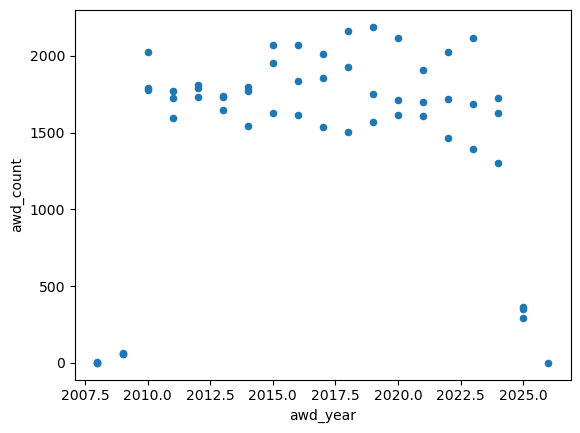

In [4]:
# Query the `awards_summary_df` DataFrame to filter rows where the dir_abbr column contains specific 
# directorate abbreviations ("PHY", "CSE", "ENG", "GEO"). Then create a scatter plot with awd_year
# on the x-axis and awd_count on the y-axis. 
awards_summary_df.query('dir_abbr in ["PHY","CSE","ENG","GEO"]').plot.scatter(x='awd_year', y='awd_count')

<Axes: >

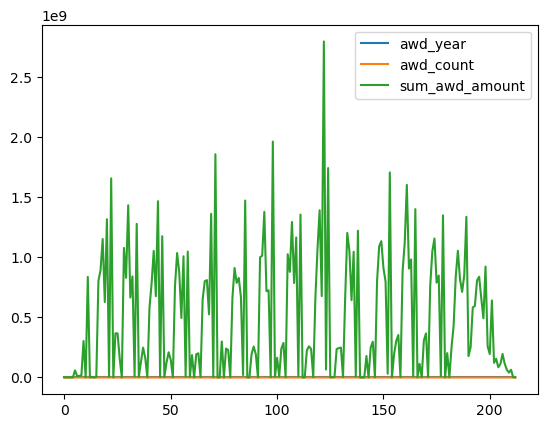

In [17]:
# Plot the awards_wide_df DataFrame to visualize the data
awards_summary_df.plot()

<Axes: xlabel='awd_year'>

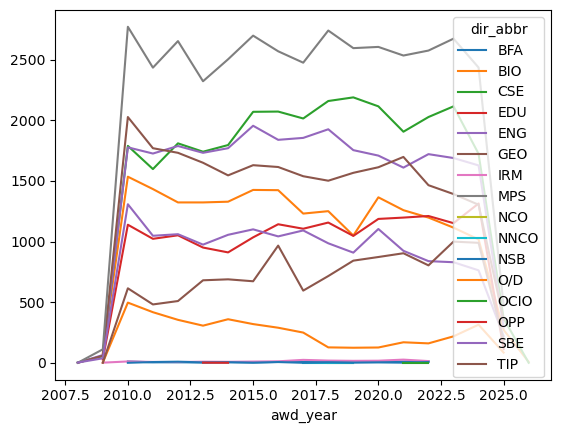

In [16]:
awards_wide_df.plot()

<Axes: xlabel='awd_year', ylabel='sum_awd_amount'>

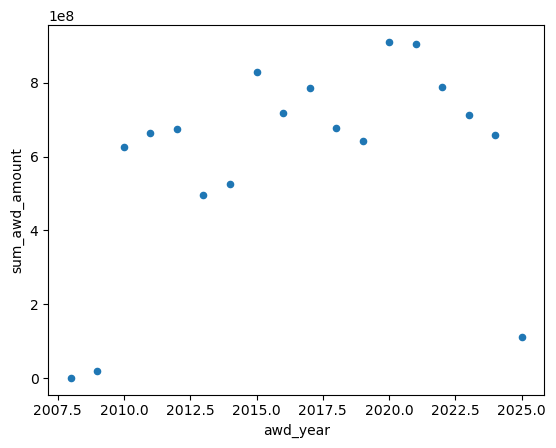

In [23]:
awards_summary_df.query('dir_abbr == "ENG"').plot.scatter(x='awd_year', y='sum_awd_amount')

<Axes: title={'center': 'Award Count: Computer and Information Science and Engineering'}, xlabel='awd_year'>

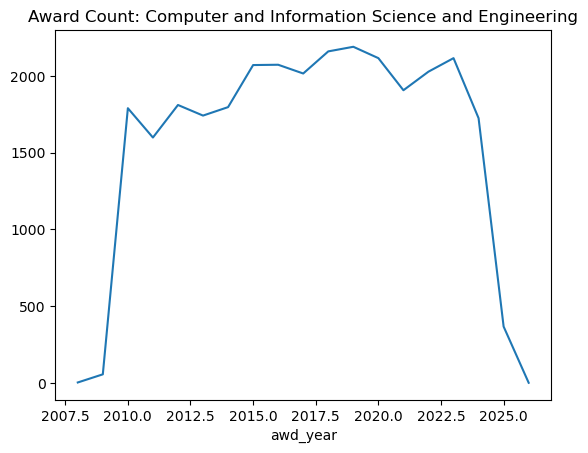

In [6]:
# Plot a line chart for the 'CSE' column in the awards_wide_df DataFrame
# Title: "Award Count: Computer and Information Science and Engineering"
awards_wide_df.plot.line(y='CSE', title='Award Count: Computer and Information Science and Engineering', legend=False)

<Axes: title={'center': 'Award Count: ENG, EDU'}, xlabel='awd_year'>

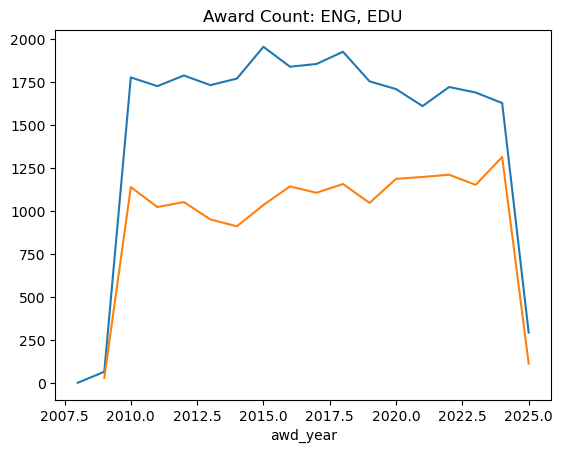

In [25]:
awards_wide_df.plot.line(y=['ENG','EDU'], title='Award Count: ENG, EDU', legend=False)

<Axes: xlabel='awd_year'>

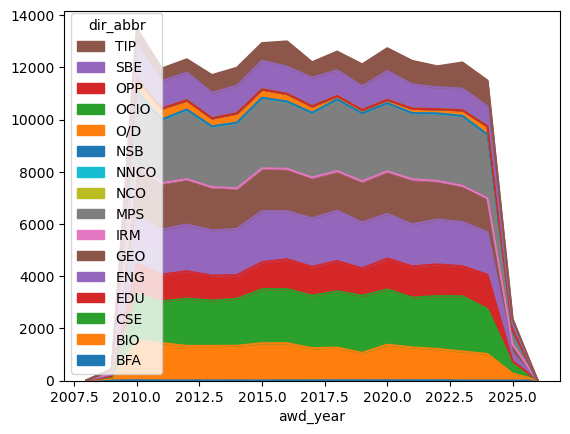

In [7]:
# Plot an area chart for the awards_wide_df DataFrame
awards_wide_df.plot.area(legend='reverse')

<Axes: title={'center': 'NSF Awards: 2024'}>

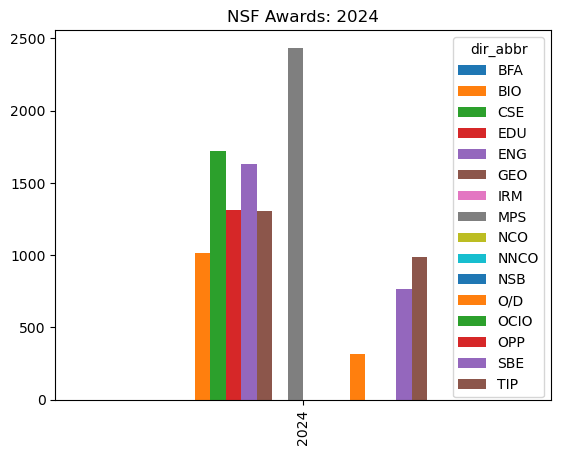

In [8]:
# Plot a bar chart for the year 2024 from the awards_wide_df DataFrame
awards_wide_df.query('awd_year == 2024') \
    .plot.bar(title='NSF Awards: 2024', xlabel="")

<Axes: xlabel='awd_year', ylabel='sum_awd_amount'>

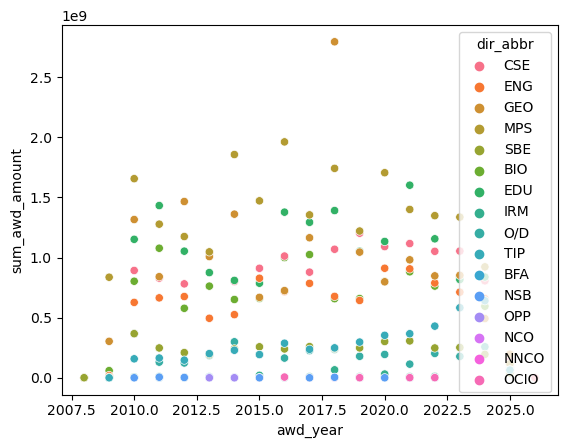

In [26]:
import seaborn as sns
sns.scatterplot(data=awards_summary_df, x='awd_year', y='sum_awd_amount', hue='dir_abbr')


<Axes: title={'center': 'NSF Awards: 2024'}, xlabel='dir_abbr'>

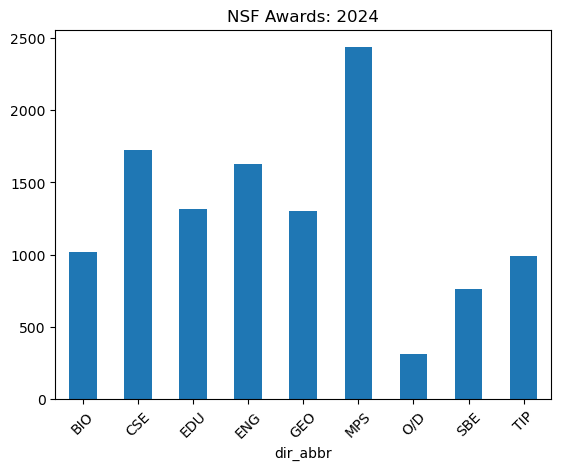

In [9]:
# Filter the awards_summary_df DataFrame for the year 2024, pivot it to have directorate abbreviations as rows,
# and award counts as values, then plot a bar chart with a title and rotated x-axis labels.
awards_summary_df.query('awd_year == 2024') \
    .pivot(index='dir_abbr', columns='awd_year', values='awd_count') \
    .plot.bar(title='NSF Awards: 2024', legend=False, rot=45)

<Axes: ylabel='Frequency'>

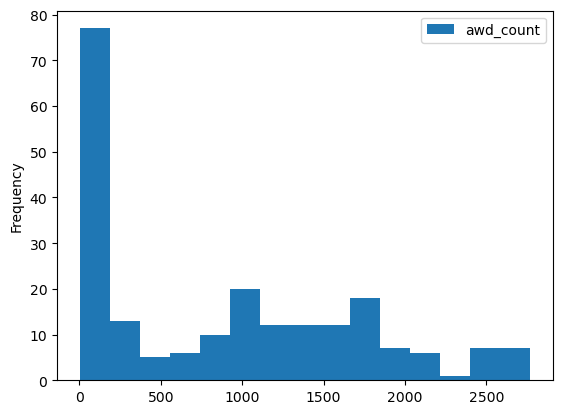

In [10]:
# Plot a histogram of the 'awd_count' column from the awards_summary_df DataFrame with 15 bins
awards_summary_df.plot.hist(y='awd_count', bins=15)

<Axes: title={'center': 'NSF Award Density: 2024'}, ylabel='Density'>

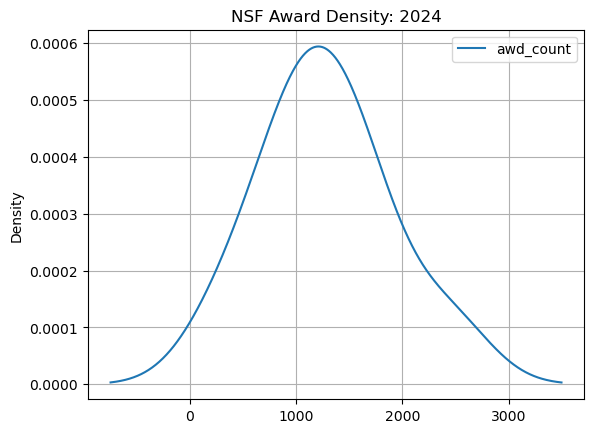

In [11]:
# Filter the awards_summary_df DataFrame for the year 2024 and plot a density plot 
# for the 'awd_count' column with a grid and a title.
awards_summary_df.query('awd_year==2024') \
    .plot.density(y='awd_count', grid=True, title='NSF Award Density: 2024')

<Axes: ylabel='awd_count'>

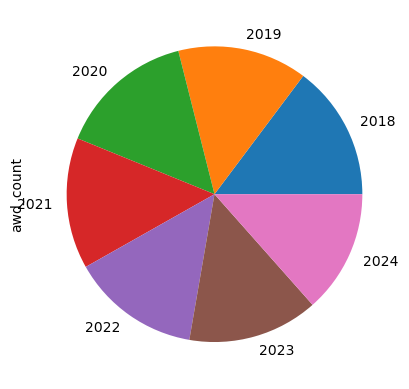

In [12]:
# Filter the awards_summary_df DataFrame for specific years (2018-2024),
# group by 'awd_year', sum the 'awd_count' column, and plot a pie chart.
awards_summary_df.query('awd_year in (2018,2019,2020,2021,2022,2023,2024)') \
    .groupby('awd_year').awd_count.sum().plot.pie()

array([[<Axes: title={'center': 'BFA'}, ylabel='awd_year'>,
        <Axes: title={'center': 'BIO'}, ylabel='awd_year'>,
        <Axes: title={'center': 'CSE'}, ylabel='awd_year'>,
        <Axes: title={'center': 'EDU'}, ylabel='awd_year'>],
       [<Axes: title={'center': 'ENG'}, ylabel='awd_year'>,
        <Axes: title={'center': 'GEO'}, ylabel='awd_year'>,
        <Axes: title={'center': 'IRM'}, ylabel='awd_year'>,
        <Axes: title={'center': 'MPS'}, ylabel='awd_year'>],
       [<Axes: title={'center': 'NCO'}, ylabel='awd_year'>,
        <Axes: title={'center': 'NNCO'}, ylabel='awd_year'>,
        <Axes: title={'center': 'NSB'}, ylabel='awd_year'>,
        <Axes: title={'center': 'O/D'}, ylabel='awd_year'>],
       [<Axes: title={'center': 'OCIO'}, ylabel='awd_year'>,
        <Axes: title={'center': 'OPP'}, ylabel='awd_year'>,
        <Axes: title={'center': 'SBE'}, ylabel='awd_year'>,
        <Axes: title={'center': 'TIP'}, ylabel='awd_year'>]], dtype=object)

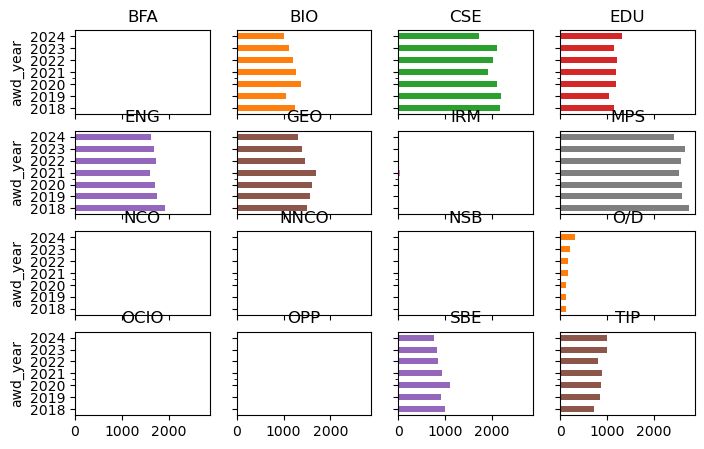

In [13]:
# Plot a horizontal bar chart for the specified years (2018-2024) from the awards_wide_df DataFrame.
# Each directorate abbreviation is plotted as a separate subplot, arranged in a 4x4 layout.
awards_wide_df.query('awd_year in (2018,2019,2020,2021,2022,2023,2024)').plot.barh(
    sharey=True, legend=False, subplots=True, layout=(4, 4), figsize=(8,5))